# Project Title

Retail Sales Analysis and Sales Prediction

#Objective

Analyze retail sales data to:

- Understand sales patterns
- Identify top-performing products
- Find factors affecting sales
- Predict future sales using Machine Learning

In [3]:
# Load Dataset
import pandas as pd
dataset = pd.read_csv("C:/Users/Uma Maheswara Rao/Desktop/Real-World Data Project/Dataset/retail_sales.csv")
dataset.head()

,Order_ID,Product,Category,Price,Quantity,Discount,Sales
0,1001,Laptop,Electronics,50000,1,5,47500
1,1002,Mouse,Electronics,500,3,10,1350
2,1003,Keyboard,Electronics,1200,2,5,2280
3,1004,Shirt,Fashion,1500,4,15,5100
4,1005,Shoes,Fashion,2500,2,10,4500


In [5]:
# Exploration
print(dataset.shape)
print(dataset.info())
print(dataset.describe())

(20, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Order_ID  20 non-null     int64 
 1   Product   20 non-null     object
 2   Category  20 non-null     object
 3   Price     20 non-null     int64 
 4   Quantity  20 non-null     int64 
 5   Discount  20 non-null     int64 
 6   Sales     20 non-null     int64 
dtypes: int64(5), object(2)
memory usage: 1.2+ KB
None
         Order_ID         Price   Quantity   Discount         Sales
count    20.00000     20.000000  20.000000  20.000000     20.000000
mean   1010.50000   8122.500000   3.800000   7.900000   9723.500000
std       5.91608  16159.830599   2.912767   6.137889  14454.007011
min    1001.00000    200.000000   1.000000   0.000000   1350.000000
25%    1005.75000    875.000000   2.000000   5.000000   2925.000000
50%    1010.50000   1250.000000   3.000000   6.500000   4250.000000
75%    1015.25000

# Check Missing Values

In [6]:
print(dataset.isnull().sum())

Order_ID    0
Product     0
Category    0
Price       0
Quantity    0
Discount    0
Sales       0
dtype: int64


# Total Sales by Category

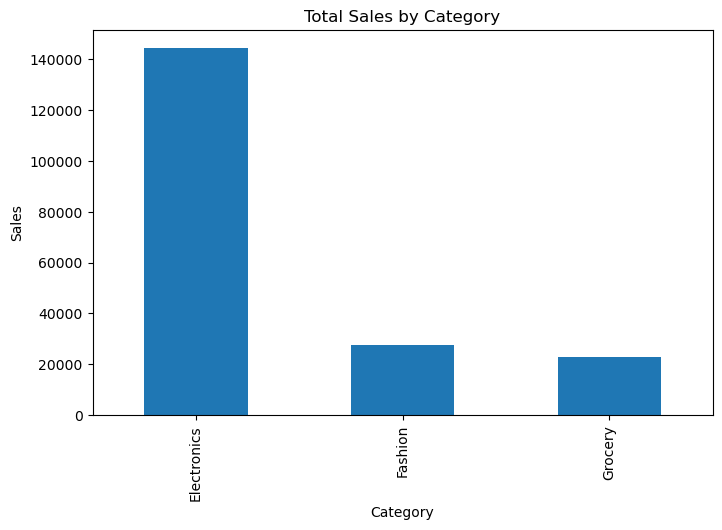

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

category_sales = dataset.groupby(
    'Category'
)['Sales'].sum()
plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')
plt.title("Total Sales by Category")
plt.ylabel("Sales")
plt.show()

# Product-wise Sales

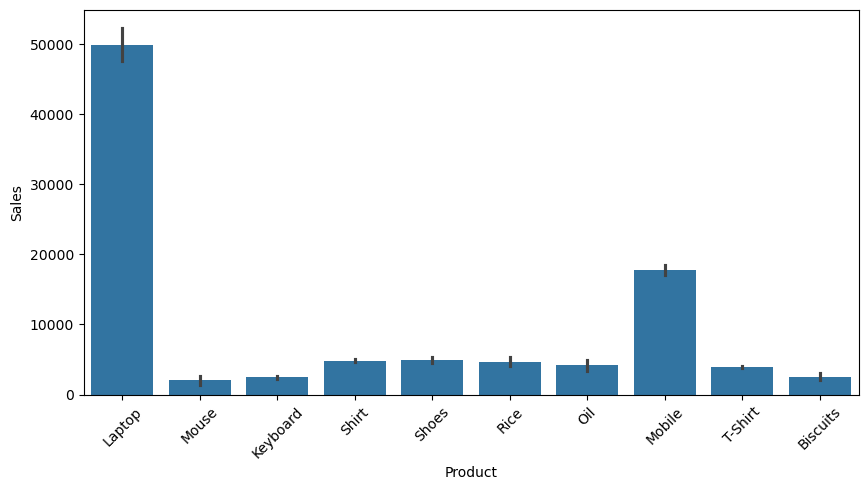

In [8]:
plt.figure(figsize=(10,5))
sns.barplot(
    x='Product',
    y='Sales',
    data=dataset
)
plt.xticks(rotation=45)
plt.show()

# Quantity Distribution

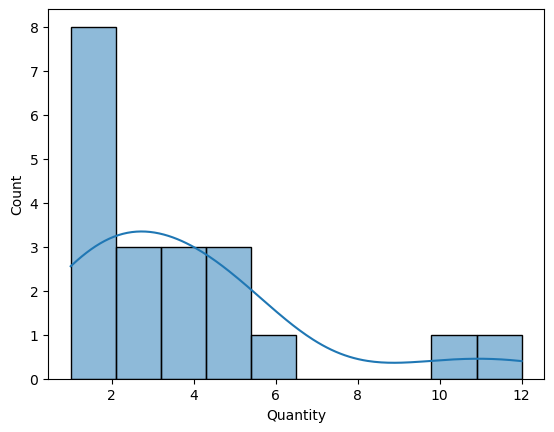

In [9]:
sns.histplot(
    dataset['Quantity'],
    bins=10,
    kde=True
)

plt.show()

# Correlation Heatmap

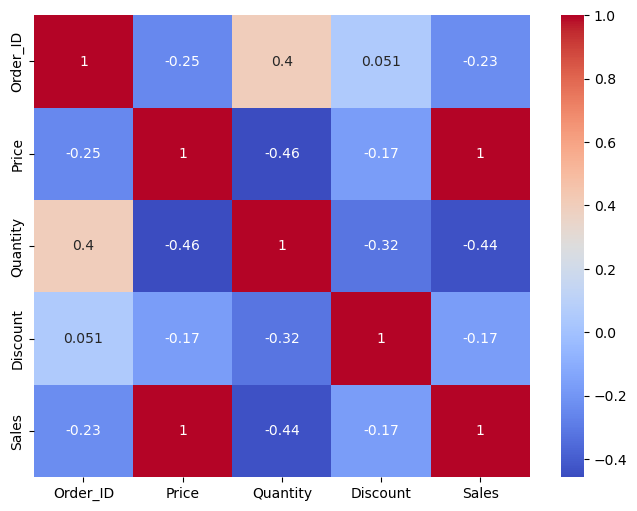

In [10]:
numeric_data = dataset.select_dtypes(
    include='number'
)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

# Sales vs Quantity

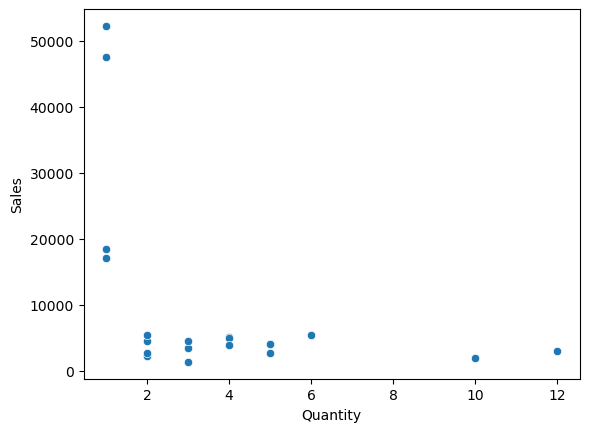

In [11]:
sns.scatterplot(
    x='Quantity',
    y='Sales',
    data=dataset
)

plt.show()

# Machine Learning Prediction

Predict Sales using:

- Price
- Quantity
- Discount

In [12]:
from sklearn.model_selection import train_test_split

feature_columns = [
    'Price',
    'Quantity',
    'Discount'
]

X = dataset[feature_columns]

y = dataset['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Linear Regression

In [15]:
from sklearn.linear_model import LinearRegression
linear_regression_model = LinearRegression()
linear_regression_model.fit(
    X_train,
    y_train
)
predictions = linear_regression_model.predict(
    X_test
)

#Evaluate Model
from sklearn.metrics import r2_score
score = r2_score(
    y_test,
    predictions
)
print("R2 Score:", score)

R2 Score: 0.9981053456528922


# Actual vs Predicted Visualization

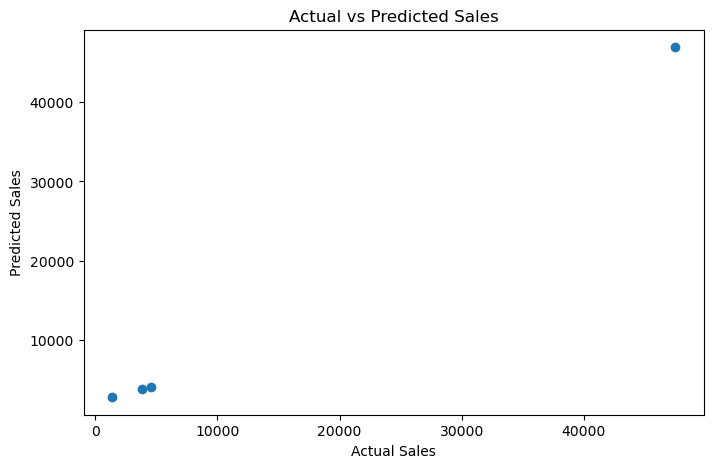

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    predictions
)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title(
    "Actual vs Predicted Sales"
)

plt.show()